In [16]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
import sys

sys.path.append('..')
from config import DATA_PATH
from pathlib import Path
from utils import get_main_freq_traj

np.random.seed(0)

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

In [3]:
splits = {"train": TRAIN_PATH, "test": TEST_PATH}
file_records = []

for split_name, split_path in splits.items():
    wavs = list(split_path.glob("*.WAV"))
    for wav_path in wavs:
        file_records.append({
            "filename": wav_path.name,
            "split": split_name,
            "full_path": wav_path,
        })

file_df = pd.DataFrame(file_records)

print(file_df["split"].value_counts())
print(f"Total .WAV files: {len(file_df)}")

split
train    20265
test      2251
Name: count, dtype: int64
Total .WAV files: 22516


In [4]:
n_sample = 200
sample_df = file_df.sample(n=min(n_sample, len(file_df)), random_state=0)

info_rows = []
for _, row in sample_df.iterrows():
    info = sf.info(row["full_path"])
    info_rows.append({
        "filename": row["filename"],
        "split": row["split"],
        "samplerate": info.samplerate,
        "duration_s": info.duration,
        "channels": info.channels,
    })

info_df = pd.DataFrame(info_rows)
print("Unique sample rates found (Hz):", info_df["samplerate"].unique())
print("Unique channel counts found:", info_df["channels"].unique())
print(info_df.groupby("split")["duration_s"].describe())

Unique sample rates found (Hz): [250000]
Unique channel counts found: [1]
       count      mean       std       min       25%       50%       75%  \
split                                                                      
test    21.0  0.054480  0.032573  0.017604  0.033604  0.044804  0.064004   
train  179.0  0.060974  0.033029  0.009604  0.036804  0.051204  0.076804   

            max  
split            
test   0.147204  
train  0.172804  


Loaded DBA_9858_888.WAV (train): sr=250000, duration=0.0432s, max_amplitude=0.0951


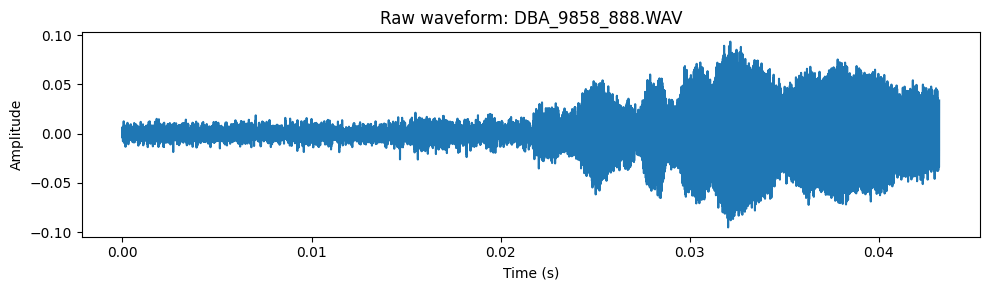

In [5]:
def load_audio(wav_path, target_sr=None):
    """Load a wav file as mono float32. can  resample to target_sr"""
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if target_sr is not None and sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    return audio.astype(np.float32), sr

test_row = file_df.iloc[0]
audio, sr = load_audio(test_row["full_path"])

print(f"Loaded {test_row['filename']} ({test_row['split']}): sr={sr}, "
      f"duration={len(audio)/sr:.4f}s, max_amplitude={np.abs(audio).max():.4f}")

plt.figure(figsize=(10, 3))
plt.plot(np.linspace(0, len(audio)/sr, len(audio)), audio)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Raw waveform: {test_row['filename']}")
plt.tight_layout()
plt.show()


In [8]:
# helper method to create a quick spectrogram for visualization --> TODO move to larger helper method file?  
def quick_spectrogram(sig, sr, n_fft=1024, hop_length=128):
    S = np.abs(librosa.stft(sig, n_fft=n_fft, hop_length=hop_length, window="hamming"))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    times = librosa.frames_to_time(np.arange(S.shape[1]), sr=sr, hop_length=hop_length)
    return librosa.amplitude_to_db(S, ref=np.max), freqs, times

In [6]:
n_check = 500
check_df = file_df.sample(n=min(n_check, len(file_df)), random_state=1)

issues = []
silence_thresh = 1e-4

for _, row in check_df.iterrows():
    try:
        a, s = load_audio(row["full_path"])
        if np.abs(a).max() < silence_thresh:
            issues.append({"filename": row["filename"], "split": row["split"], "issue": "near-silent"})
            continue
        _ = bandpass_filter(a, s, LOW_HZ_TYPICAL, HIGH_HZ_TYPICAL)
    except Exception as e:
        issues.append({"filename": row["filename"], "split": row["split"], "issue": f"error: {e}"})

issues_df = pd.DataFrame(issues)
print(f"Checked {len(check_df)} files, found {len(issues_df)} issues")
if len(issues_df) > 0:
    print(issues_df.groupby("split")["issue"].value_counts())
    issues_df.to_csv("flagged_files.csv", index=False)

Checked 500 files, found 500 issues
split  issue                                       
test   error: name 'bandpass_filter' is not defined     42
train  error: name 'bandpass_filter' is not defined    458
Name: count, dtype: int64


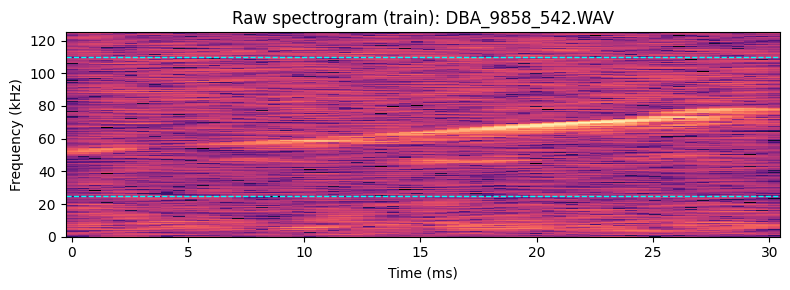

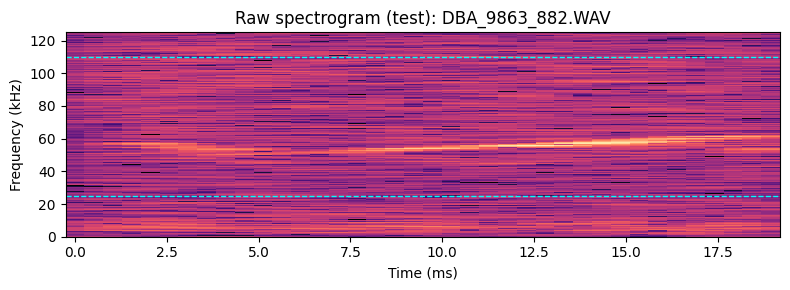

In [ ]:
# checking if the audio files are already filtered and bandpass filtered
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]
    a, s = load_audio(sample_row["full_path"])
    S_db, freqs, times = quick_spectrogram(a, s)

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times*1000, freqs/1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.ylim(0, 125)
    plt.axhline(25, color="cyan", linestyle="--", linewidth=1)
    plt.axhline(110, color="cyan", linestyle="--", linewidth=1)
    plt.title(f"Raw spectrogram ({split_name}): {sample_row['filename']}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.tight_layout()
    plt.show()

In [11]:
def get_spectrogram(audio_path, n_fft=1024, hop_length=None):
    """
    Loads audio from path, applies bandpass filter, returns raw magnitude spectrogram.
    Matches the (times, freqs, magnitude) signature get_main_freq_traj expects.
    """
    if hop_length is None:
        hop_length = n_fft // 4

    audio, sr = load_audio(audio_path)
    filtered = bandpass_filter(audio, sr, low_hz=25000, high_hz=110000)

    S = np.abs(librosa.stft(filtered, n_fft=n_fft, hop_length=hop_length, window="hamming"))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    times = librosa.frames_to_time(np.arange(S.shape[1]), sr=sr, hop_length=hop_length)

    return times, freqs, S

In [13]:
def bandpass_filter(audio, sr, low_hz=25000, high_hz=110000, order=4):
    nyq = sr / 2
    high_hz = min(high_hz, nyq * 0.98)
    low_hz = min(low_hz, high_hz * 0.5)
    sos = butter(order, [low_hz, high_hz], btype="band", fs=sr, output="sos")
    return sosfiltfilt(sos, audio)

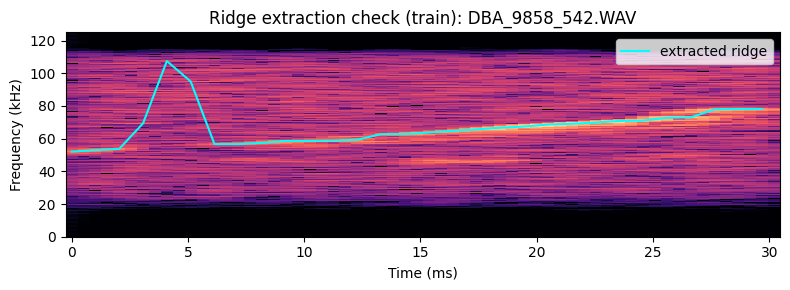

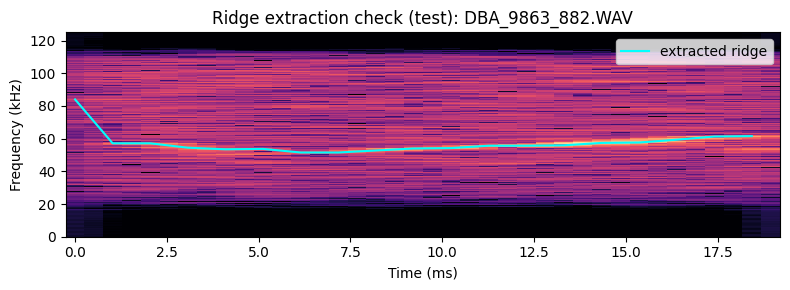

In [19]:
for split_name in ["train", "test"]:
    sample_row = file_df[file_df["split"] == split_name].sample(1, random_state=2).iloc[0]
    path = sample_row["full_path"]

    # get  raw spectrogram for plotting the background
    a, s = load_audio(path)
    filtered = bandpass_filter(a, s, low_hz=25000, high_hz=110000)
    S_db, freqs, times_bg = quick_spectrogram(filtered, s)

    # Get the extracted trajectory
    times_traj, freq_traj = get_main_freq_traj(path)

    plt.figure(figsize=(8, 3))
    plt.pcolormesh(times_bg*1000, freqs/1000, S_db, shading="auto", cmap="magma", vmin=-60, vmax=0)
    plt.plot(times_traj*1000, freq_traj/1000, color="cyan", linewidth=1.5, label="extracted ridge")
    plt.ylim(0, 125)
    plt.title(f"Ridge extraction check ({split_name}): {sample_row['filename']}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Frequency (kHz)")
    plt.legend()
    plt.tight_layout()
    plt.show()